In [1]:
%pip install -q sysidentpy

import time
import os
from pathlib import Path

import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from itertools import combinations_with_replacement
from sysidentpy.neural_network import NARXNN
from sysidentpy.basis_function import Polynomial
import matplotlib.pyplot as plt

SEED = 42  
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(device)}")
elif device.type == "mps":
    print("GPU: Apple MPS")

try:
    # Collega Google Drive (colab fallback supportato da VS Code)
    from google.colab import drive
    drive.mount('/content/drive')
    
    # IMPORTANTE: Modifica questo percorso col path del tuo file su google drive!
    # Puoi caricare manualmente la cartella Benchmark_EEG_medium nel tuo Drive.
    data_path = Path('/content/drive/MyDrive/Benchmark_EEG_medium/Benchmark_EEG_medium.mat')

except ImportError:
    # Fallback per l'esecuzione in locale
    data_path = Path('./Benchmark_EEG_medium/Benchmark_EEG_medium.mat')

data = sio.loadmat(data_path)
EEGdata = data['EEGdata'][0]  # Cell array: EEGdata{1..10}

# Extract data from all participants
# Structure: EEGdata{S}.angle / .comp with shape [M, P, N]
# M = realizations, P = periods, N = samples at 2048 Hz

u_all = []
y_all = []

for S in range(len(EEGdata)):
    participant = EEGdata[S]
    u_participant = participant['angle'][0, 0]  # shape: (M, P, N)
    y_participant = participant['comp'][0, 0]   # shape: (M, P, N)
    
    # Reshape [M, P, N] -> [M*P, N] to get all trials
    M, P, N = u_participant.shape
    u_trials_s = u_participant.reshape(M * P, N)
    y_trials_s = y_participant.reshape(M * P, N)
    u_all.append(u_trials_s)
    y_all.append(y_trials_s)

u_trials = np.vstack(u_all).astype(np.float32)   # float32 subito: -50% RAM vs float64
y_trials = np.vstack(y_all).astype(np.float32)

# Libera le liste intermedie — non servono più
del u_all, y_all, data, EEGdata, participant

n_trials  = u_trials.shape[0]
trial_len = u_trials.shape[1]

print(f"Loaded dataset with {u_trials.size} samples total")
print(f"Total dataset: {n_trials} trials, {trial_len} samples/trial")


Note: you may need to restart the kernel to use updated packages.
Device: mps
GPU: Apple MPS
Loaded dataset with 3010560 samples total
Total dataset: 1470 trials, 2048 samples/trial


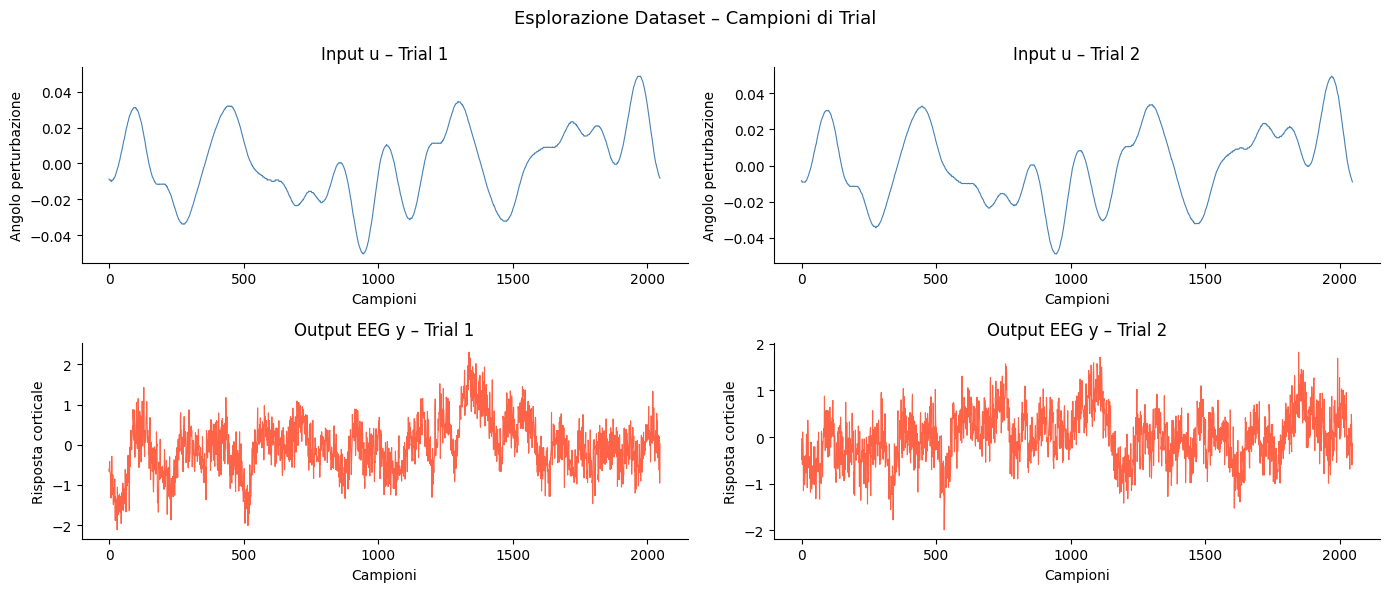

u – media: -0.0000  std: 0.0208  range: [-0.055, 0.055]
y – media: 0.0006  std: 0.7727  range: [-7.129, 5.767]


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle("Esplorazione Dataset – Campioni di Trial", fontsize=13)

for i, ax in enumerate(axes[0]):
    ax.plot(u_trials[i], color='steelblue', lw=0.8)
    ax.set_title(f"Input u – Trial {i+1}")
    ax.set_xlabel("Campioni")
    ax.set_ylabel("Angolo perturbazione")

for i, ax in enumerate(axes[1]):
    ax.plot(y_trials[i], color='tomato', lw=0.8)
    ax.set_title(f"Output EEG y – Trial {i+1}")
    ax.set_xlabel("Campioni")
    ax.set_ylabel("Risposta corticale")

plt.tight_layout()
plt.savefig("data_exploration.png", dpi=120)
plt.show()

# Statistiche di base
print(f"u – media: {u_trials.mean():.4f}  std: {u_trials.std():.4f}  range: [{u_trials.min():.3f}, {u_trials.max():.3f}]")
print(f"y – media: {y_trials.mean():.4f}  std: {y_trials.std():.4f}  range: [{y_trials.min():.3f}, {y_trials.max():.3f}]")


In [3]:
# Split 70/15/15% per trial interi — nessun data leakage temporale
n_train = int(np.floor(0.70 * n_trials))
n_val   = int(np.floor(0.15 * n_trials))
n_test  = n_trials - n_train - n_val

idx      = np.random.permutation(n_trials)
train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train + n_val]
test_idx  = idx[n_train + n_val:]

# Usa view numpy (np.ascontiguousarray solo se serve) — nessuna copia
u_train_trials = u_trials[train_idx]
y_train_trials = y_trials[train_idx]
u_val_trials   = u_trials[val_idx]
y_val_trials   = y_trials[val_idx]
u_test_trials  = u_trials[test_idx]
y_test_trials  = y_trials[test_idx]

# Libera l'array originale — gli split sono le uniche copie necessarie
del u_trials, y_trials

print(f"Train: {n_train} trial  Val: {n_val}  Test: {n_test}")
print(f"RAM stimata dati: {(u_train_trials.nbytes + y_train_trials.nbytes + u_val_trials.nbytes + y_val_trials.nbytes + u_test_trials.nbytes + y_test_trials.nbytes) / 1024**2:.0f} MB")

Train: 1029 trial  Val: 220  Test: 221
RAM stimata dati: 23 MB


In [4]:
scaler_u = StandardScaler()
scaler_y = StandardScaler()

# fit sul training flat — usa reshape(-1,1) che è una view, non copia
u_train_s = scaler_u.fit_transform(u_train_trials.reshape(-1, 1)).astype(np.float32)
y_train_s = scaler_y.fit_transform(y_train_trials.reshape(-1, 1)).astype(np.float32)

def scale_trials(scaler, trials_2d):
    """Scala e converte in float32 in un solo passaggio — nessuna copia float64."""
    return scaler.transform(trials_2d.reshape(-1, 1)).astype(np.float32).reshape(trials_2d.shape)

u_val_trials_s  = scale_trials(scaler_u, u_val_trials)
y_val_trials_s  = scale_trials(scaler_y, y_val_trials)
u_test_trials_s = scale_trials(scaler_u, u_test_trials)
y_test_trials_s = scale_trials(scaler_y, y_test_trials)
utrain_trials_s = scale_trials(scaler_u, u_train_trials)
ytrain_trials_s = scale_trials(scaler_y, y_train_trials)


print(f"Normalizzazione OK — dtype: {utrain_trials_s.dtype}  shape: {utrain_trials_s.shape}")
print(f"RAM scaled arrays: {(utrain_trials_s.nbytes + ytrain_trials_s.nbytes + u_val_trials_s.nbytes + y_val_trials_s.nbytes + u_test_trials_s.nbytes + y_test_trials_s.nbytes) / 1024**2:.0f} MB")

Normalizzazione OK — dtype: float32  shape: (1029, 2048)
RAM scaled arrays: 23 MB


In [5]:
NY = 20
NU = 20
DEGREE = 1
H1 = 30
EPOCHS = 500
LEARNING_RATE = 1e-3
INPUT_SIZE = NY + NU  # 40

# ── parametri adattivi per device ──────────────────────────────────────────
if device.type == "cuda":
    BATCH_SIZE   = 254   # Colab T4: batch più piccolo per dataset piccolo
    NUM_WORKERS  = 2     # Colab: fork OK su Linux
    PIN_MEMORY   = True  # accelera CPU→GPU transfer
    USE_AMP      = True  # mixed precision fp16 su T4 tensor cores (~2x speedup)
elif device.type == "mps":
    BATCH_SIZE   = 128   # M4: memoria unificata condivisa con OS
    NUM_WORKERS  = 0     # Mac: fork causa hang
    PIN_MEMORY   = False # MPS: pin_memory non ha senso su memoria unificata
    USE_AMP      = False # MPS: autocast non supportato
else:
    BATCH_SIZE   = 64
    NUM_WORKERS  = 0
    PIN_MEMORY   = False
    USE_AMP      = False

print(f"Config: BATCH={BATCH_SIZE}  WORKERS={NUM_WORKERS}  PIN={PIN_MEMORY}  AMP={USE_AMP}")

class SimpleNARXNet(nn.Module):
    """MLP a due hidden layer."""
    def __init__(self, input_size=INPUT_SIZE, hidden=H1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),     nn.Tanh(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


net = SimpleNARXNet().to(device)
print(f"Parametri: {count_params(net):,}")
print(net)

try:
    net = torch.compile(net, mode="default")
    print("torch.compile: attivo")
except Exception:
    print("torch.compile: non disponibile")


Config: BATCH=128  WORKERS=0  PIN=False  AMP=False
Parametri: 2,191
SimpleNARXNet(
  (net): Sequential(
    (0): Linear(in_features=40, out_features=30, bias=True)
    (1): Tanh()
    (2): Linear(in_features=30, out_features=30, bias=True)
    (3): Tanh()
    (4): Linear(in_features=30, out_features=1, bias=True)
  )
)
torch.compile: attivo


In [10]:
# Cella 3: Inizializzazione modello
input_size = NY + NU
# Inizializziamo il modello su cpu perché SysIdentPy invia i tensori su cpu
net = SimpleNARXNet().to('cpu')

model = NARXNN(
    net=net,
    ylag=NY,
    xlag=NU,
    basis_function=Polynomial(degree=DEGREE),
    loss_func='mse_loss',
    optimizer='Adam',
    optim_params={},
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    device=device.type if device.type == "cuda" else "cpu",  # SysIdentPy vuole esattamente la stringa 'cpu' o 'cuda'
    verbose=False,
)

print(f"NARX input size: {input_size}")

NARX input size: 40


In [11]:
print("Training NARX...")
t0 = time.perf_counter()
model.fit(X=u_train_s, y=y_train_s)
train_time_s = time.perf_counter() - t0
print(f"Training completed in {train_time_s:.2f} s")


Training NARX...
Training completed in 3109.05 s


In [12]:
def predict_per_trial(model, u_trials_s, y_trials_s, steps_ahead=None):
    preds_list = []
    for i in range(len(u_trials_s)):
        u_t = u_trials_s[i].reshape(-1, 1)
        y_t = y_trials_s[i].reshape(-1, 1)
        yhat_t = model.predict(X=u_t, y=y_t, steps_ahead=steps_ahead)
        preds_list.append(np.asarray(yhat_t).ravel())
    return preds_list

def evaluate_per_trial(preds_list, y_trials_s, scaler_y):
    vafs, nrmses, rmses = [], [], []
    for i, yhat_s in enumerate(preds_list):
        y_true_s = y_trials_s[i].ravel()
        n = len(yhat_s)
        y_true_s = y_true_s[-n:]
        y_true = scaler_y.inverse_transform(y_true_s.reshape(-1, 1)).ravel()
        y_pred = scaler_y.inverse_transform(yhat_s.reshape(-1, 1)).ravel()
        var_true = np.var(y_true)
        if var_true > 0:
            vafs.append((1 - np.var(y_true - y_pred) / var_true) * 100.0)
        rmse_v = np.sqrt(mean_squared_error(y_true, y_pred))
        rmses.append(rmse_v)
        denom = np.max(y_true) - np.min(y_true)
        if denom > 0:
            nrmses.append(rmse_v / denom)
    return {
        'VAF (%)': np.mean(vafs),
        'NRMSE': np.mean(nrmses),
        'RMSE': np.mean(rmses),
    }

val_1step_preds = predict_per_trial(model, u_val_trials_s, y_val_trials_s, steps_ahead=1)
val_free_preds  = predict_per_trial(model, u_val_trials_s, y_val_trials_s, steps_ahead=None)
test_1step_preds = predict_per_trial(model, u_test_trials_s, y_test_trials_s, steps_ahead=1)
test_free_preds  = predict_per_trial(model, u_test_trials_s, y_test_trials_s, steps_ahead=None)

res_val_1step  = evaluate_per_trial(val_1step_preds,  y_val_trials_s,  scaler_y)
res_val_free   = evaluate_per_trial(val_free_preds,   y_val_trials_s,  scaler_y)
res_test_1step = evaluate_per_trial(test_1step_preds, y_test_trials_s, scaler_y)
res_test_free  = evaluate_per_trial(test_free_preds,  y_test_trials_s, scaler_y)

print('\nRISULTATI MODELLO STANDARD')
for name, r in [
    ('val 1-step', res_val_1step),
    ('val free-run', res_val_free),
    ('test 1-step', res_test_1step),
    ('test free-run', res_test_free),
]:
    print(f"[{name}] VAF={r['VAF (%)']:.2f}% NRMSE={r['NRMSE']:.4f} RMSE={r['RMSE']:.5f}")


RISULTATI MODELLO STANDARD
[val 1-step] VAF=71.86% NRMSE=0.0809 RMSE=0.38487
[val free-run] VAF=-1.14% NRMSE=0.1672 RMSE=0.81887
[test 1-step] VAF=71.18% NRMSE=0.0823 RMSE=0.38401
[test free-run] VAF=-0.63% NRMSE=0.1691 RMSE=0.81285


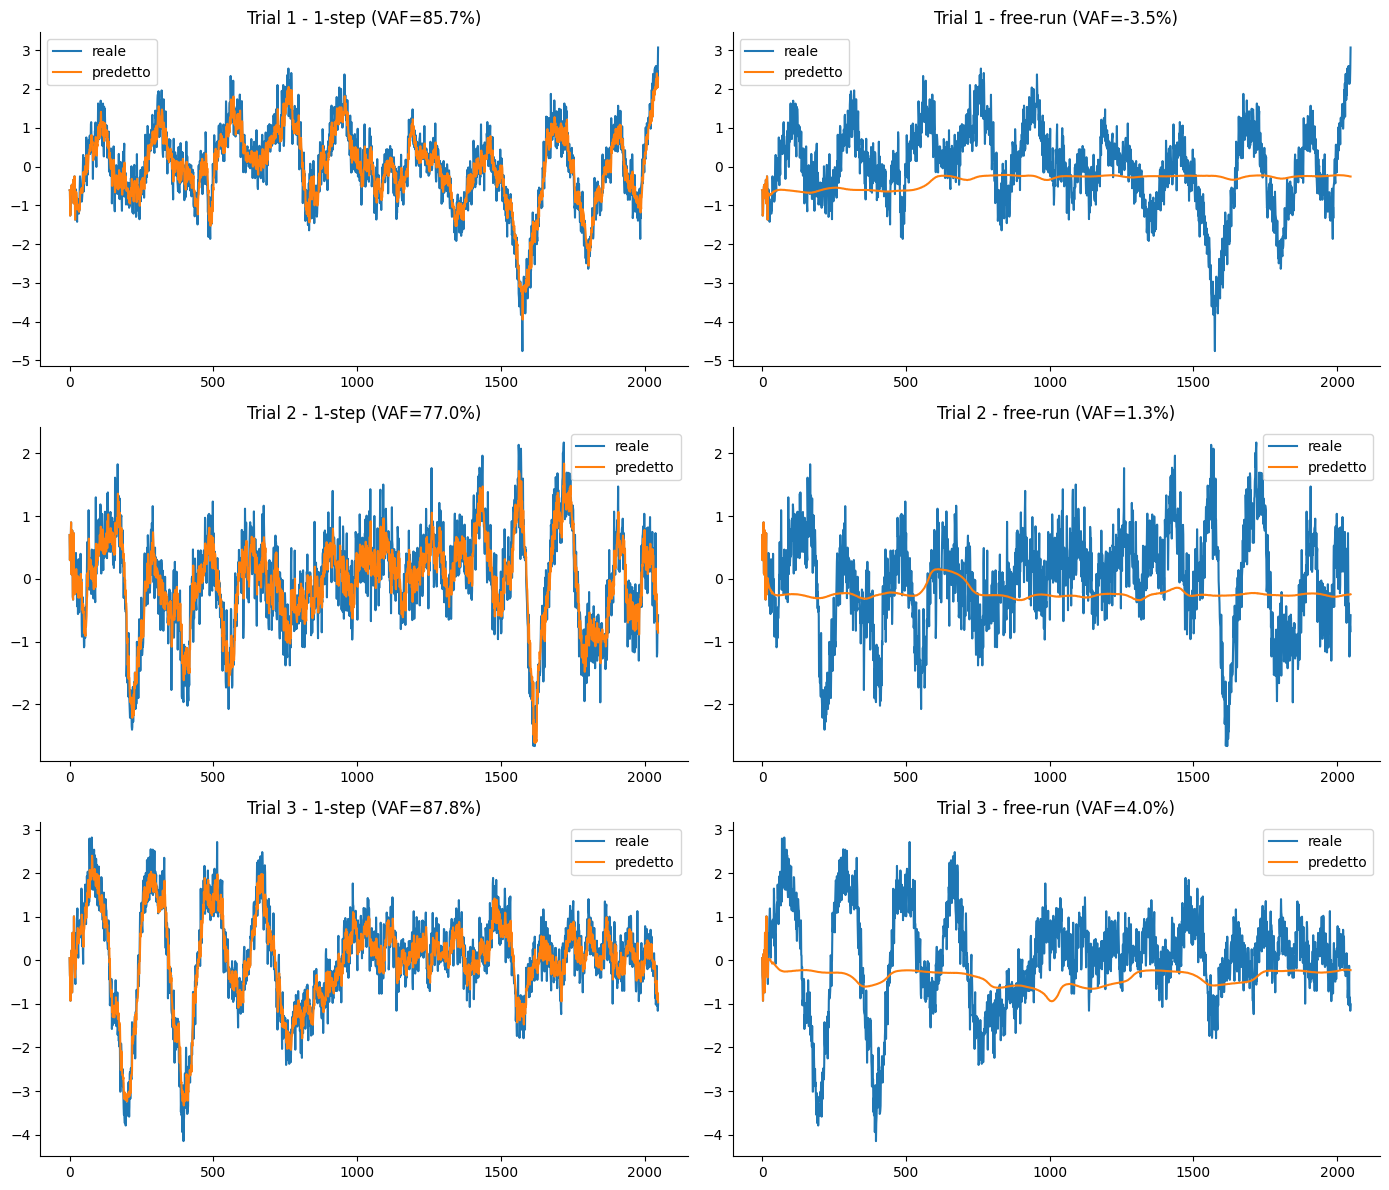

In [13]:
n_show = min(3, len(test_free_preds))
fig, axes = plt.subplots(n_show, 2, figsize=(14, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for i in range(n_show):
    for j, (preds, label) in enumerate([(test_1step_preds, '1-step'), (test_free_preds, 'free-run')]):
        yhat_s = preds[i]
        y_true_s = y_test_trials_s[i].ravel()[-len(yhat_s):]
        y_true = scaler_y.inverse_transform(y_true_s.reshape(-1, 1)).ravel()
        y_pred = scaler_y.inverse_transform(yhat_s.reshape(-1, 1)).ravel()
        vaf_v = (1 - np.var(y_true - y_pred) / np.var(y_true)) * 100
        axes[i, j].plot(y_true, label='reale')
        axes[i, j].plot(y_pred, label='predetto')
        axes[i, j].set_title(f'Trial {i+1} - {label} (VAF={vaf_v:.1f}%)')
        axes[i, j].legend()
plt.tight_layout()
plt.show()

In [14]:
import torch.optim as optim

def build_regressor_at_t(y_buf, u_seq, t, NY, NU):
    y_lags = [y_buf[t - k] for k in range(1, NY + 1)]
    u_lags = [u_seq[t - k] for k in range(1, NU + 1)]
    return y_lags + u_lags


def train_scheduled_sampling(net, us_trials, ys_trials, NY, NU,
                              epochs=500, lr=1e-3, batch_size=64,
                              ss_start=0.0, ss_end=0.4, warmup_epochs=50,
                              noise_std=0.02):
    """
    Improvements over baseline:
      - Sigmoid curriculum computed over the POST-warmup range only (was a bug)
      - Gaussian noise augmentation on regressor inputs (noise_std)
      - Best-weights tracking: restores the lowest-loss checkpoint at the end
    """
    net = net.to(device)
    optimizer = optim.Adam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=20
    )
    criterion = nn.MSELoss()
    maxlag = max(NY, NU)
    n_trials = len(us_trials)
    loss_history = []

    # Best-weights tracking
    best_loss = float("inf")
    best_state = None

    for epoch in range(epochs):
        # Sigmoid curriculum computed correctly over post-warmup range
        if epoch < warmup_epochs:
            p_free = 0.0   # pure teacher-forcing during warmup
        else:
            progress = (epoch - warmup_epochs) / max(epochs - warmup_epochs - 1, 1)
            sig = 1.0 / (1.0 + np.exp(-8.0 * (progress - 0.5)))
            p_free = ss_start + (ss_end - ss_start) * sig

        Xall_ep, Yall_ep = [], []

        for i in range(n_trials):
            unp  = us_trials[i].ravel().tolist()
            ybuf = ys_trials[i].ravel().tolist()
            y_np = ys_trials[i].ravel()
            T = len(unp)

            net.eval()
            with torch.no_grad():
                for t in range(maxlag, T):
                    if np.random.random() < p_free:
                        reg = torch.tensor(
                            build_regressor_at_t(ybuf, unp, t, NY, NU),
                            dtype=torch.float32).to(device)
                        ybuf[t] = net(reg).item()
                    else:
                        ybuf[t] = y_np[t]   # teacher-forced

            Xall_ep += [build_regressor_at_t(ybuf, unp, t, NY, NU)
                        for t in range(maxlag, T)]
            Yall_ep += [y_np[t] for t in range(maxlag, T)]

        Xall = torch.tensor(Xall_ep, dtype=torch.float32).to(device)
        Yall = torch.tensor(Yall_ep, dtype=torch.float32).unsqueeze(1).to(device)

        # Gaussian noise augmentation on regressor inputs
        if noise_std > 0:
            Xall = Xall + torch.randn_like(Xall) * noise_std

        net.train()
        perm = torch.randperm(len(Xall))
        ep_loss, nb = 0.0, 0
        for start in range(0, len(Xall), batch_size):
            ib = perm[start:start + batch_size]
            optimizer.zero_grad()
            loss = criterion(net(Xall[ib]), Yall[ib])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 0.5)
            optimizer.step()
            ep_loss += loss.item(); nb += 1

        avg_loss = ep_loss / max(nb, 1)
        scheduler.step(avg_loss)
        loss_history.append(avg_loss)

        # Save best checkpoint
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_state = {k: v.clone() for k, v in net.state_dict().items()}

    # Restore best weights found during training
    if best_state is not None:
        net.load_state_dict(best_state)
        print(f"Restored best checkpoint (loss={best_loss:.6f})")

    return net, loss_history


def predict_free_run_manual(net, u_trial_s, y_trial_s, NY, NU):
    net = net.to(device)
    net.eval()
    T = len(u_trial_s)
    max_lag = max(NY, NU)
    y_buf = y_trial_s.ravel().tolist()
    u_seq = u_trial_s.ravel().tolist()
    preds = []
    with torch.no_grad():
        for t in range(max_lag, T):
            reg = torch.tensor([build_regressor_at_t(y_buf, u_seq, t, NY, NU)],
                               dtype=torch.float32).to(device)
            yhat = net(reg).item()
            y_buf[t] = yhat
            preds.append(yhat)
    return np.array(preds, dtype=np.float32)


In [15]:
torch.manual_seed(SEED)
np.random.seed(SEED)
net_ss = SimpleNARXNet().to(device)

print(f"Parametri SS model: {count_params(net_ss):,}")
print("Training con Scheduled Sampling...")
t0 = time.perf_counter()
net_ss, ss_loss = train_scheduled_sampling(
    net_ss, utrain_trials_s, ytrain_trials_s,
    NY=NY, NU=NU,
    epochs=500,          # was 300
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    ss_start=0.0,
    ss_end=0.4,
    warmup_epochs=50,    # 50 epochs pure teacher-forcing before ramp starts
    noise_std=0.02,      # Gaussian noise augmentation on regressor inputs
)
print(f"Training SS completato in {time.perf_counter() - t0:.1f} s")


Parametri SS model: 2,191
Training con Scheduled Sampling...


: 


RISULTATI SCHEDULED SAMPLING
Val  -> VAF=4.44% NRMSE=0.1904
Test -> VAF=3.17% NRMSE=0.1881


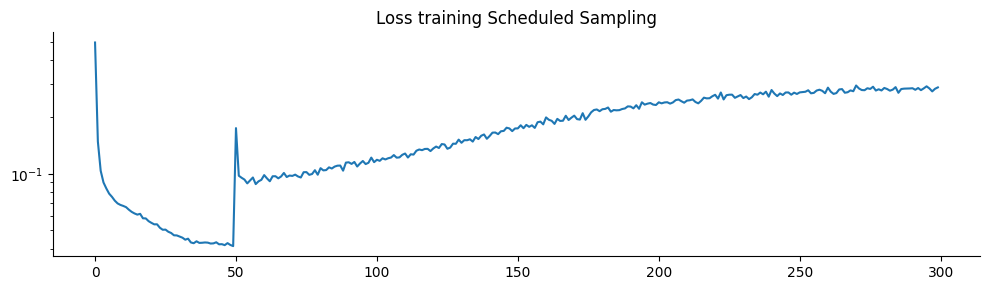

In [ ]:
def eval_ss_model(net_ss, u_trials_s, y_trials_s, scaler_y, NY, NU):
    vafs, nrmses = [], []
    for i in range(len(u_trials_s)):
        yhat_s = predict_free_run_manual(net_ss, u_trials_s[i], y_trials_s[i], NY, NU)
        n = len(yhat_s)
        y_true_s = y_trials_s[i].ravel()[-n:]
        y_true = scaler_y.inverse_transform(y_true_s.reshape(-1, 1)).ravel()
        y_pred = scaler_y.inverse_transform(yhat_s.reshape(-1, 1)).ravel()
        vt = np.var(y_true)
        if vt > 0:
            vafs.append((1 - np.var(y_true - y_pred) / vt) * 100)
        denom = np.max(y_true) - np.min(y_true)
        if denom > 0:
            nrmses.append(np.sqrt(np.mean((y_true - y_pred) ** 2)) / denom)
    return np.mean(vafs), np.mean(nrmses)

vaf_val, nrmse_val = eval_ss_model(net_ss, u_val_trials_s, y_val_trials_s, scaler_y, NY, NU)
vaf_test, nrmse_test = eval_ss_model(net_ss, u_test_trials_s, y_test_trials_s, scaler_y, NY, NU)

print('\nRISULTATI SCHEDULED SAMPLING')
print(f"Val  -> VAF={vaf_val:.2f}% NRMSE={nrmse_val:.4f}")
print(f"Test -> VAF={vaf_test:.2f}% NRMSE={nrmse_test:.4f}")

plt.figure(figsize=(10, 3))
plt.plot(ss_loss)
plt.yscale('log')
plt.title('Loss training Scheduled Sampling')
plt.tight_layout()
plt.show()

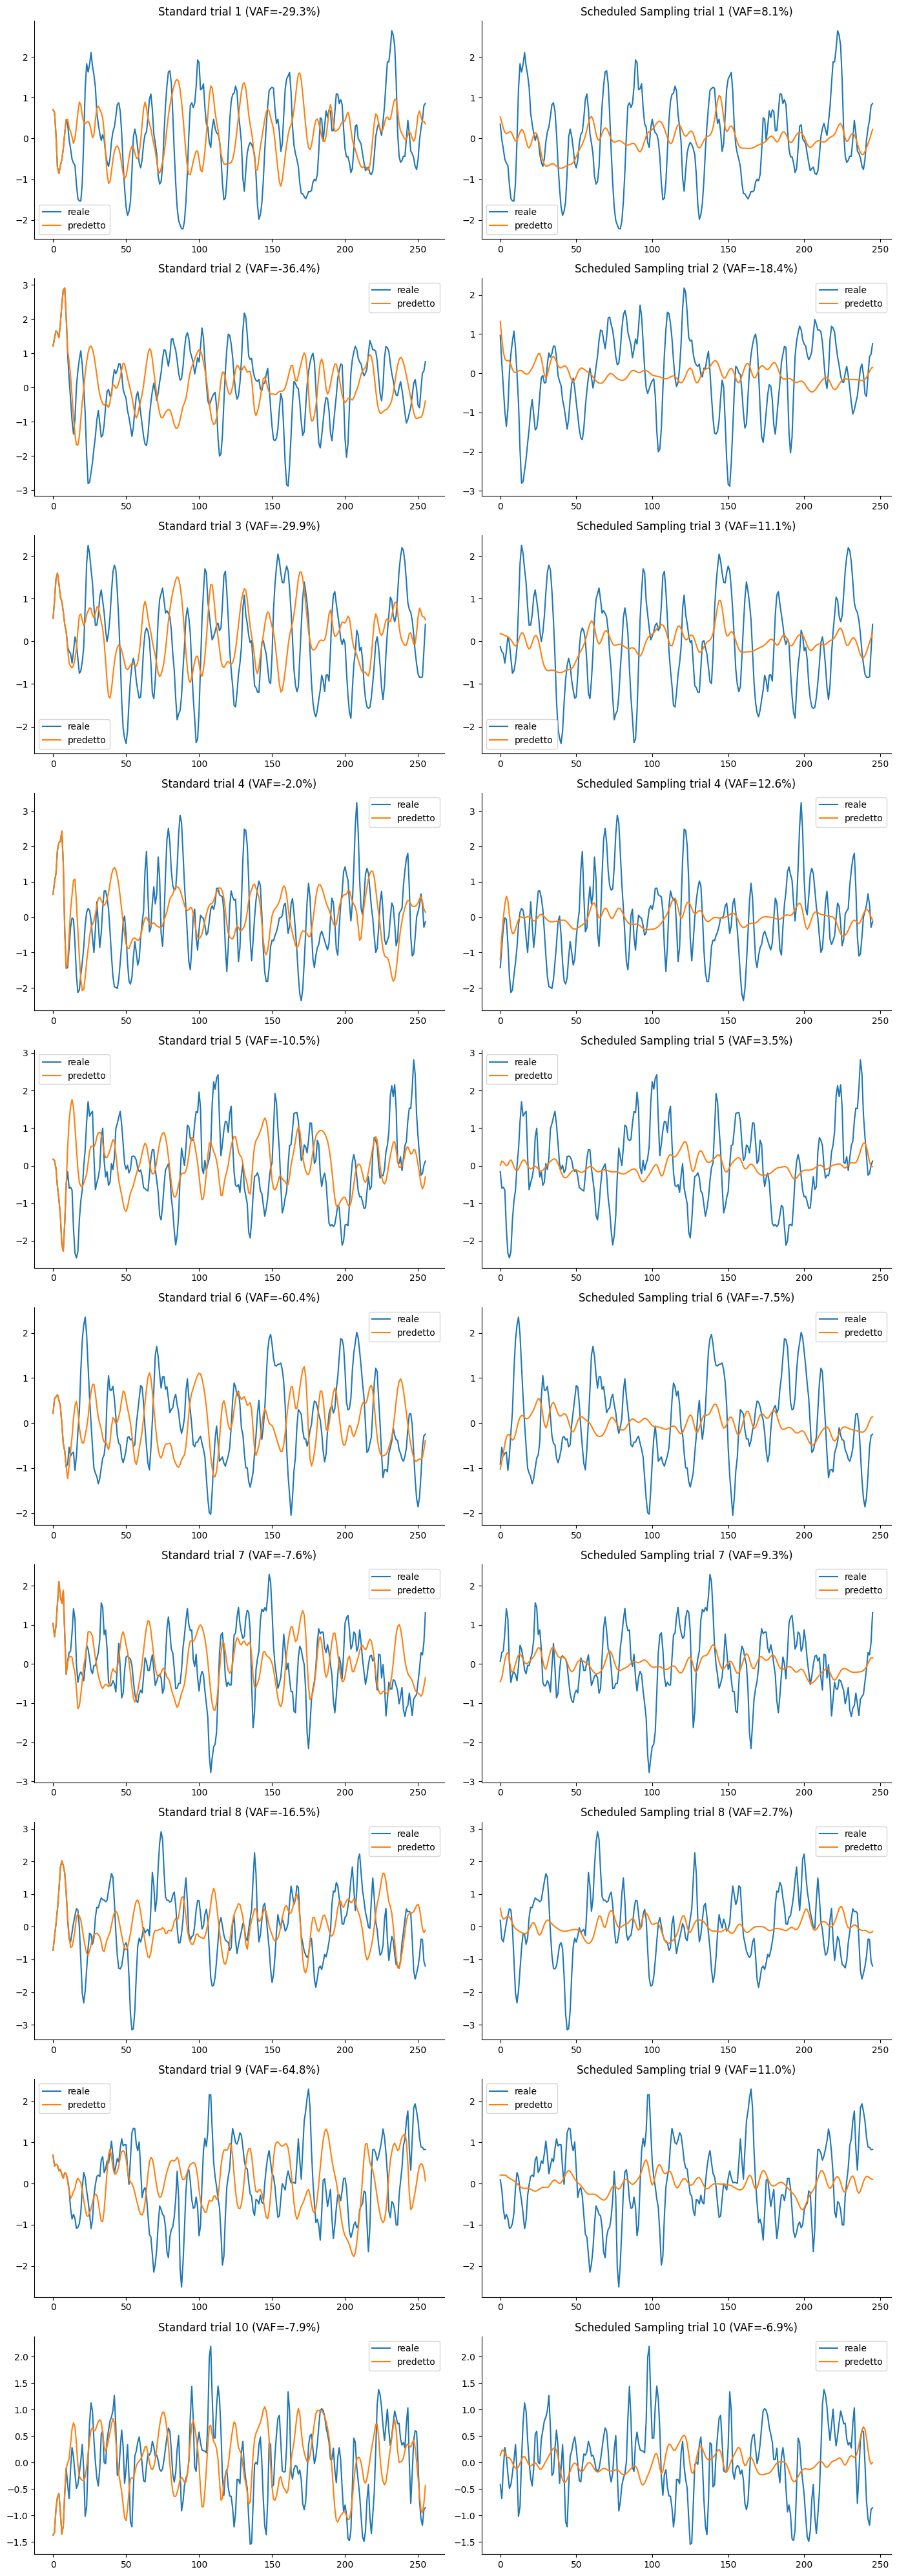

In [ ]:
n_show = min(10, len(u_test_trials_s))
fig, axes = plt.subplots(n_show, 2, figsize=(14, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for i in range(n_show):
    yhat_std_s = test_free_preds[i]
    yt_s = y_test_trials_s[i].ravel()[-len(yhat_std_s):]
    yt_std = scaler_y.inverse_transform(yt_s.reshape(-1, 1)).ravel()
    yp_std = scaler_y.inverse_transform(yhat_std_s.reshape(-1, 1)).ravel()
    vaf_std = (1 - np.var(yt_std - yp_std) / np.var(yt_std)) * 100

    yhat_ss_s = predict_free_run_manual(net_ss, u_test_trials_s[i], y_test_trials_s[i], NY, NU)
    yt_s2 = y_test_trials_s[i].ravel()[-len(yhat_ss_s):]
    yt_ss = scaler_y.inverse_transform(yt_s2.reshape(-1, 1)).ravel()
    yp_ss = scaler_y.inverse_transform(yhat_ss_s.reshape(-1, 1)).ravel()
    vaf_ss = (1 - np.var(yt_ss - yp_ss) / np.var(yt_ss)) * 100

    axes[i, 0].plot(yt_std, label='reale')
    axes[i, 0].plot(yp_std, label='predetto')
    axes[i, 0].set_title(f'Standard trial {i+1} (VAF={vaf_std:.1f}%)')
    axes[i, 0].legend()

    axes[i, 1].plot(yt_ss, label='reale')
    axes[i, 1].plot(yp_ss, label='predetto')
    axes[i, 1].set_title(f'Scheduled Sampling trial {i+1} (VAF={vaf_ss:.1f}%)')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()